# Bivariat dataanalyse -- beregninger i Python

Dette notatet inneholder alle beregningene fra Beamer-forelesningen *Bivariat dataanalyse*:
krysstabeller, stablet stolpediagram, spredningsdiagram, kovarians, Pearsons r, linearitet,
korrelasjons-/kovariansmatrise og enkel lineaer regresjon.

Alle tall er reproduserbare -- kjor cellene i rekkefolge.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ORANGE = "#E8743B"
BLUE = "#1f4e8c"
GRAY = "#888888"
GREEN = "#2ca02c"
plt.rcParams["figure.figsize"] = (6.0, 4.0)
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 1. Krysstabeller

En krysstabell systematiserer data med flere kategoriske variabler. `pandas.crosstab` teller
forekomster automatisk.

In [2]:
data = pd.DataFrame({
    "Nasjonalitet": [
        "Norsk", "Norsk", "Svensk",
        "Finsk", "Norsk", "Finsk",
        "Svensk", "Norsk", "Svensk"],
    "Kjaeledyr": [
        "Hund", "Katt", "Katt", "Ulv",
        "Hund", "Hund", "Katt", "Katt",
        "Katt"]})

tabell = pd.crosstab(data["Nasjonalitet"], data["Kjaeledyr"])
print(tabell)

Kjaeledyr     Hund  Katt  Ulv
Nasjonalitet                 
Finsk            1     0    1
Norsk            2     2    0
Svensk           0     3    0


**Radprosenter** (`normalize="index"`) viser andelen innad i hver nasjonalitet i stedet for
rene antall:

In [3]:
tabell_prosent = pd.crosstab(
    data["Nasjonalitet"], data["Kjaeledyr"], normalize="index")
print((tabell_prosent * 100).round(1))

Kjaeledyr     Hund   Katt   Ulv
Nasjonalitet                   
Finsk         50.0    0.0  50.0
Norsk         50.0   50.0   0.0
Svensk         0.0  100.0   0.0


## 2. Stablet og gruppert stolpediagram

Datasettet gjenbrukes fra kjikvadrattest-forelesningen: kjonnsfordeling i de fem landsdelene.
Et **gruppert** stolpediagram viser antall side ved side, mens et **stablet/prosentvis**
stolpediagram normaliserer hver soyle til 100 % og viser andelen kvinner/menn innad i hver
landsdel -- nyttig nar gruppene har svaert ulik storrelse.

In [4]:
landsdeler = ["Nord-Norge", "Trondelag", "Vestlandet", "Sorlandet", "Ostlandet"]
kvinne = np.array([69, 33, 145, 14, 215])
mann = np.array([84, 28, 127, 42, 243])

tot = kvinne + mann
andel_k = kvinne / tot
andel_m = mann / tot

for ld, ak in zip(landsdeler, andel_k):
    print(f"{ld:12s}  kvinneandel = {ak:.1%}")

Nord-Norge    kvinneandel = 45.1%
Trondelag     kvinneandel = 54.1%
Vestlandet    kvinneandel = 53.3%
Sorlandet     kvinneandel = 25.0%
Ostlandet     kvinneandel = 46.9%


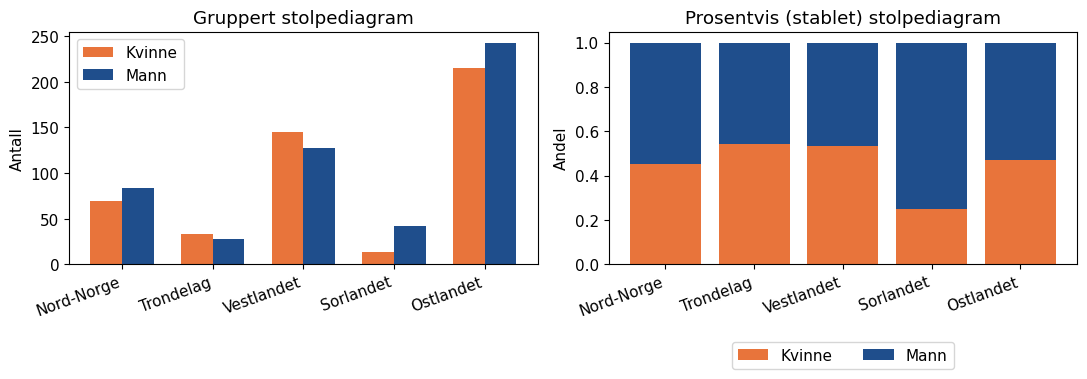


Lavest kvinneandel: Sorlandet (25.0%)


In [5]:
x = np.arange(len(landsdeler))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(x - w/2, kvinne, w, label="Kvinne", color=ORANGE)
axes[0].bar(x + w/2, mann, w, label="Mann", color=BLUE)
axes[0].set_xticks(x)
axes[0].set_xticklabels(landsdeler, rotation=20, ha="right")
axes[0].set_ylabel("Antall")
axes[0].set_title("Gruppert stolpediagram")
axes[0].legend()

axes[1].bar(x, andel_k, color=ORANGE, label="Kvinne")
axes[1].bar(x, andel_m, bottom=andel_k, color=BLUE, label="Mann")
axes[1].set_xticks(x)
axes[1].set_xticklabels(landsdeler, rotation=20, ha="right")
axes[1].set_ylabel("Andel")
axes[1].set_title("Prosentvis (stablet) stolpediagram")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2)

plt.tight_layout()
plt.show()

print(f"\nLavest kvinneandel: {landsdeler[np.argmin(andel_k)]} ({andel_k.min():.1%})")

Sorlandet skiller seg klart ut med lavest kvinneandel (25 %) -- konsistent med
kjikvadrattesten som fant en signifikant sammenheng mellom kjonn og landsdel.

## 3. Spredningsdiagram (scatter plot)

Er det en sammenheng mellom boligareal og boligpris? Et syntetisk datasett med 60 boliger
brukes til a illustrere.

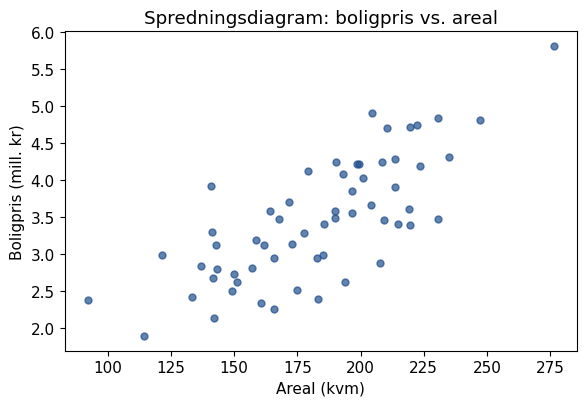

In [6]:
n_bolig = 60
areal = rng.normal(180, 45, n_bolig).clip(70, 300)
boligpris = 150_000 + 18_800 * areal + rng.normal(0, 700_000, n_bolig)
boligpris = boligpris.clip(800_000, None)

plt.figure(figsize=(6, 4.2))
plt.scatter(areal, boligpris / 1e6, color=BLUE, alpha=0.7, s=25)
plt.xlabel("Areal (kvm)")
plt.ylabel("Boligpris (mill. kr)")
plt.title("Spredningsdiagram: boligpris vs. areal")
plt.tight_layout()
plt.show()

**Tolkning av spredningsdiagram:**

- **Positiv sammenheng:** punktene danner et monster fra nederst venstre til overst hoyre.
- **Negativ sammenheng:** punktene danner et monster fra overst venstre til nederst hoyre.
- **Ingen sammenheng:** ingen synlig retning i punktskyen.

Under simuleres tre datasett med kjent korrelasjon (rho = 0.85, -0.85 og 0) for a illustrere
de tre tilfellene.

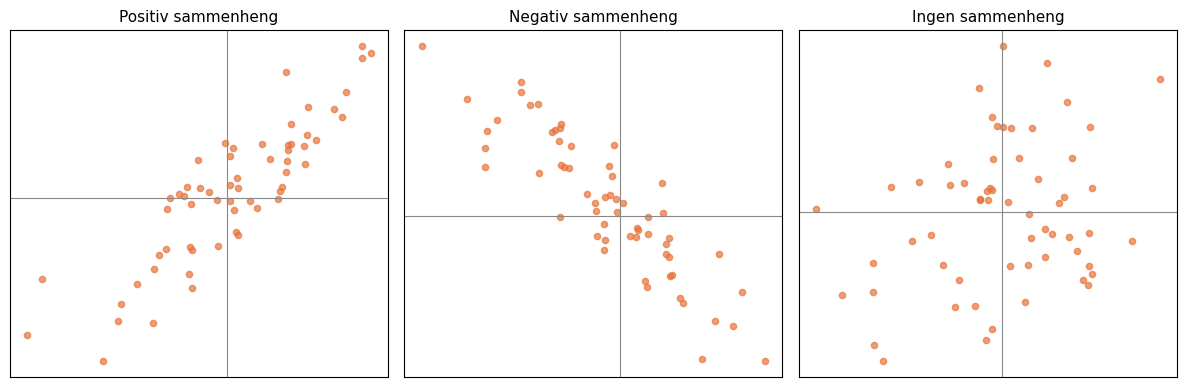

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, rho, title in zip(
        axes, [0.85, -0.85, 0.0],
        ["Positiv sammenheng", "Negativ sammenheng", "Ingen sammenheng"]):
    cov = np.array([[1, rho], [rho, 1]])
    pts = rng.multivariate_normal([0, 0], cov, 60)
    ax.scatter(pts[:, 0], pts[:, 1], color=ORANGE, alpha=0.7, s=20)
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.axvline(0, color=GRAY, lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 4. Kovarians

For **en** variabel maler variansen gjennomsnittlig kvadrert avvik fra middelverdien:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar x)^2$$

For **to** variabler ganger kovariansen avvikene i x og y sammen i stedet for a kvadrere --
dette maler om avvikene "henger sammen":

$$s_{xy} = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar x)(y_i - \bar y)$$

**Eksempel:** reklamebudsjett (x) og salg (y) for 10 bedrifter.

In [8]:
reklame = np.array([23, 14, 57, 82, 11, 45, 72, 29, 62, 34])
salg = np.array([19, 12, 48, 53, 24, 32, 43, 17, 36, 18])

xbar, ybar = reklame.mean(), salg.mean()
print(f"xbar (reklame) = {xbar:.1f}")
print(f"ybar (salg)    = {ybar:.1f}")

# Bedrift 4 (indeks 3): avvik og bidrag til kovariansen
i = 3
avvik_x = reklame[i] - xbar
avvik_y = salg[i] - ybar
print(f"\nBedrift {i+1}: x4-xbar = {avvik_x:.1f}, y4-ybar = {avvik_y:.1f}")
print(f"Bidrag: {avvik_x:.1f} * {avvik_y:.1f} = {avvik_x*avvik_y:.2f}")

xbar (reklame) = 42.9
ybar (salg)    = 30.2

Bedrift 4: x4-xbar = 39.1, y4-ybar = 22.8
Bidrag: 39.1 * 22.8 = 891.48


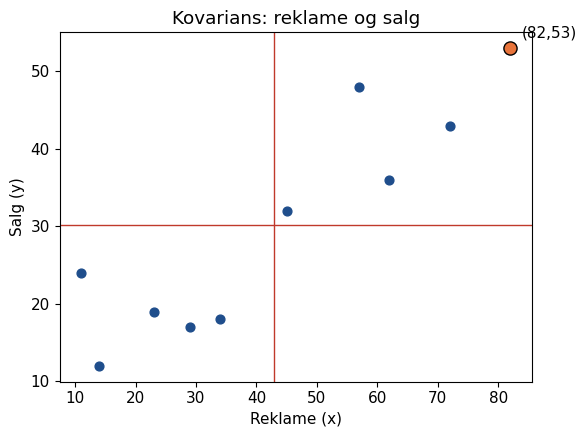

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(reklame, salg, color=BLUE, s=40, zorder=3)
ax.scatter([reklame[i]], [salg[i]], color=ORANGE, s=90, zorder=4, edgecolor="black")
ax.axhline(ybar, color="#c0392b", lw=1)
ax.axvline(xbar, color="#c0392b", lw=1)
ax.annotate(f"({reklame[i]},{salg[i]})", (reklame[i], salg[i]),
            textcoords="offset points", xytext=(8, 8))
ax.set_xlabel("Reklame (x)")
ax.set_ylabel("Salg (y)")
ax.set_title("Kovarians: reklame og salg")
plt.tight_layout()
plt.show()

In [10]:
# ddof=1: del pa (n-1), som i formelen over
kov = np.cov(reklame, salg, ddof=1)[0, 1]
print(f"kovarians s_xy = {kov:.2f}")

kovarians s_xy = 318.69


Positiv kovarians betyr positiv samvariasjon: mer reklame henger sammen med hoyere salg.

**OBS:** kovariansens *storrelse* er vanskelig a tolke direkte -- den avhenger av
malenhetene til x og y. Derfor normaliserer vi den til korrelasjon.

## 5. Korrelasjon: Pearsons r

$$r = \frac{\text{kovarians}}{\sqrt{\text{varians for }x}\cdot\sqrt{\text{varians for }y}}
= \frac{S_{xy}}{\sqrt{S_{xx}}\cdot\sqrt{S_{yy}}}$$

En "normalisert kovarians" -- alltid mellom -1 og 1, uavhengig av malenhet.

- $r=1$: alle punktene ligger pa en rett linje med positivt stigningstall.
- $r=-1$: alle punktene ligger pa en rett linje med negativt stigningstall.
- $r>0$: punktene danner et monster fra nederst venstre til overst hoyre.
- $r<0$: punktene danner et monster fra overst venstre til nederst hoyre.
- $r=0$: liten grad av *lineaer* sammenheng.

In [11]:
r, p = stats.pearsonr(reklame, salg)
print(f"r = {r:.3f}, p = {p:.4f}")

# eller med numpy (gir samme tall, uten p-verdi):
r2 = np.corrcoef(reklame, salg)[0, 1]
print(f"np.corrcoef gir r = {r2:.3f}")

r = 0.901, p = 0.0004
np.corrcoef gir r = 0.901


$r=0.90$ er en **svaert sterk positiv** korrelasjon: mer reklame henger tydelig sammen med
hoyere salg.

**OBS:** korrelasjon er ikke det samme som kausalitet! At to variabler samvarierer betyr
ikke at den ene forarsaker den andre.

Figuren under viser hvordan punktskyen ser ut for ulike verdier av r (simulerte data med
kjent korrelasjon):

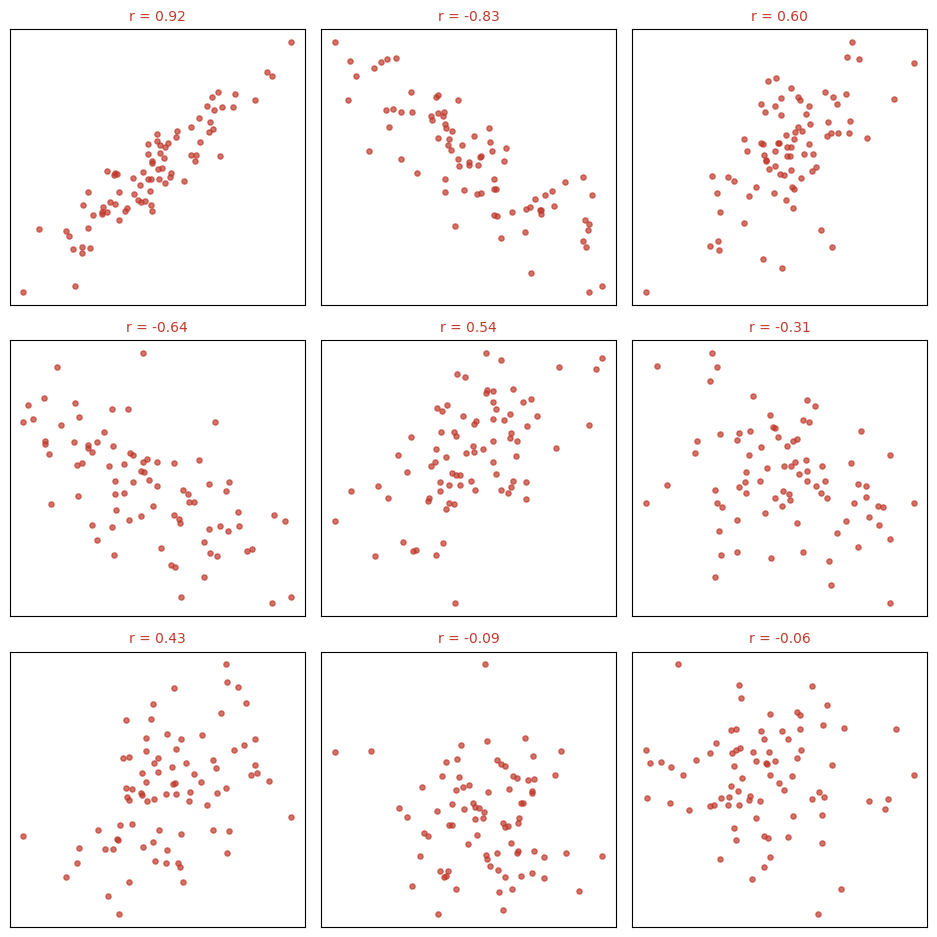

In [12]:
r_values = [0.9, -0.8, 0.7, -0.6, 0.5, -0.4, 0.3, -0.2, 0.1]
fig, axes = plt.subplots(3, 3, figsize=(9.5, 9.5))
for ax, rho in zip(axes.flat, r_values):
    cov = np.array([[1, rho], [rho, 1]])
    pts = rng.multivariate_normal([0, 0], cov, 80)
    r_emp = np.corrcoef(pts[:, 0], pts[:, 1])[0, 1]
    ax.scatter(pts[:, 0], pts[:, 1], color="#c0392b", alpha=0.7, s=14)
    ax.set_title(f"r = {r_emp:.2f}", fontsize=10, color="#c0392b")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. Linearitet

Pearsons r maler kun **lineaer** sammenheng -- en sterk, men *ikke-lineaer*, sammenheng kan
gi r naer 0. Derfor bor man *alltid* se pa spredningsdiagrammet i tillegg til a beregne r --
ikke stol blindt pa tallet!

**Klassisk eksempel:** $y = x^2$. Dette er en helt deterministisk sammenheng, men *ikke*
lineaer.

In [13]:
x_lin = np.linspace(-5, 5, 80)
y_lin = x_lin**2 + rng.normal(0, 2, 80)

r_lin, p_lin = stats.pearsonr(x_lin, y_lin)
print(f"r = {r_lin:.3f}, p = {p_lin:.4f}")
# r er naer 0, selv om det er en klar (kvadratisk) sammenheng mellom x og y!

r = 0.053, p = 0.6432


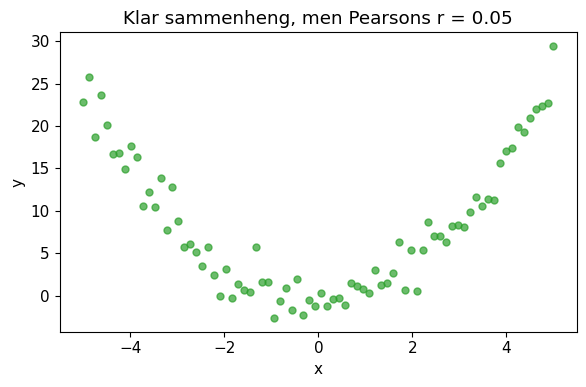

In [14]:
plt.figure(figsize=(6, 4))
plt.scatter(x_lin, y_lin, color=GREEN, alpha=0.7, s=25)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Klar sammenheng, men Pearsons r = {r_lin:.2f}")
plt.tight_layout()
plt.show()

**Konklusjon:** r ligger naer 0 -- ikke fordi det ikke er noen sammenheng, men fordi
sammenhengen ikke er lineaer. Spredningsdiagrammet avslorer dette tydelig.

## 7. Korrelasjonsmatrise og kovariansmatrise

Med **flere enn to** variabler er vi ofte interessert i korrelasjonen mellom alle par. En
korrelasjonsmatrise samler informasjon om korrelasjonen *parvis*. Matrisen er
**speilsymmetrisk** rundt diagonalen (siden $r_{xy}=r_{yx}$), og diagonalen bestar alltid av
1-ere (en variabel korrelerer perfekt med seg selv).

Syntetisk boligdatasett (n=40) med fem variabler:

In [15]:
n_h = 40
areal_h = rng.normal(150, 40, n_h).clip(60, 300)
alder_h = rng.normal(25, 12, n_h).clip(0, 60)
avstand_h = rng.normal(8, 4, n_h).clip(0.5, 25)
soverom_h = np.round(1 + areal_h / 60 + rng.normal(0, 0.5, n_h)).clip(1, 6)
boligpris_h = (150_000 + 18_800 * areal_h - 8_000 * alder_h
               - 15_000 * avstand_h + rng.normal(0, 300_000, n_h))
boligpris_h = boligpris_h.clip(500_000, None)

df = pd.DataFrame({
    "Boligpris": boligpris_h,
    "Areal": areal_h,
    "Alder": alder_h,
    "Avstand_sentrum": avstand_h,
    "Soverom": soverom_h})

korr = df.corr()
kov = df.cov()
print("Korrelasjonsmatrise:")
print(korr.round(2))

Korrelasjonsmatrise:
                 Boligpris  Areal  Alder  Avstand_sentrum  Soverom
Boligpris             1.00   0.90  -0.16             0.11     0.64
Areal                 0.90   1.00  -0.05             0.22     0.74
Alder                -0.16  -0.05   1.00            -0.21    -0.11
Avstand_sentrum       0.11   0.22  -0.21             1.00     0.19
Soverom               0.64   0.74  -0.11             0.19     1.00


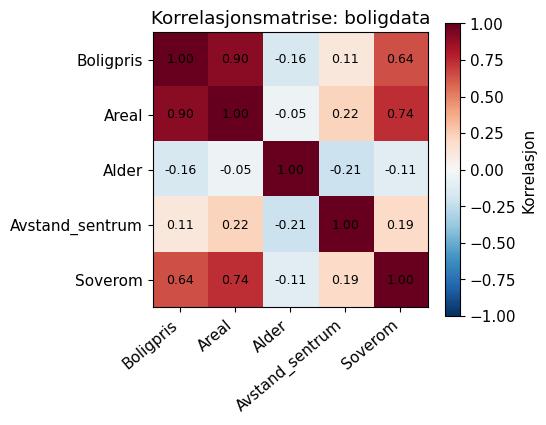

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(korr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(korr.columns)))
ax.set_yticks(range(len(korr.columns)))
ax.set_xticklabels(korr.columns, rotation=40, ha="right")
ax.set_yticklabels(korr.columns)
for i in range(len(korr)):
    for j in range(len(korr)):
        ax.text(j, i, f"{korr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Korrelasjon")
ax.set_title("Korrelasjonsmatrise: boligdata")
plt.tight_layout()
plt.show()

Mange dropper den ene halvdelen av matrisen, eller enerne langs diagonalen, siden de er
overflodig informasjon.

### Eksempel: les korrelasjonsmatrise fra SPSS-output

I "arbeidskrav h22"-datasettet (n=73 personer) er variablene Kjonn, Vekt, Hoyde_2 (hoyde som
2-aring) og Hoyde_voksen malt. SPSS gir folgende korrelasjonsmatrise (Pearsons r). Radata er
ikke tilgjengelig her, men samme tall ville man fatt i Python med `df.corr()` pa det
tilhorende datasettet -- tabellen typesettes derfor direkte fra SPSS-utskriften:

In [17]:
spss_korrelasjon = pd.DataFrame(
    {
        "Kjonn": [1.000, 0.444, 0.037, 0.783],
        "Vekt": [0.444, 1.000, 0.282, 0.605],
        "Hoyde_2": [0.037, 0.282, 1.000, 0.503],
        "Hoyde_voksen": [0.783, 0.605, 0.503, 1.000],
    },
    index=["Kjonn", "Vekt", "Hoyde_2", "Hoyde_voksen"])

print(spss_korrelasjon)
print(f"\nn = 73")
print(f"Sterkest korrelasjon med Hoyde_voksen: Kjonn (r = {spss_korrelasjon.loc['Kjonn','Hoyde_voksen']})"
      " -- sterkere enn bade Vekt og Hoyde_2.")
print(f"Korrelasjonen mellom Hoyde_2 og Kjonn er svak (r = {spss_korrelasjon.loc['Hoyde_2','Kjonn']},"
      " p = 0.757, ikke signifikant).")

              Kjonn   Vekt  Hoyde_2  Hoyde_voksen
Kjonn         1.000  0.444    0.037         0.783
Vekt          0.444  1.000    0.282         0.605
Hoyde_2       0.037  0.282    1.000         0.503
Hoyde_voksen  0.783  0.605    0.503         1.000

n = 73
Sterkest korrelasjon med Hoyde_voksen: Kjonn (r = 0.783) -- sterkere enn bade Vekt og Hoyde_2.
Korrelasjonen mellom Hoyde_2 og Kjonn er svak (r = 0.037, p = 0.757, ikke signifikant).


## 8. Regresjon

**Korrelasjon** svarer pa: er det en lineaer samvariasjon, hvor sterk, og positiv eller
negativ? **Regresjon** gar et skritt lenger: finner den lineaere *modellen* (funksjonen) som
best beskriver sammenhengen.

**Repetisjon: rett linje.** En isselger har fastlonn 600 kr/dag pluss 3 kr per solgt is:
$y = 600 + 3x$ (600 = skjaeringspunkt, 3 = stigningstall).

### Minste kvadraters metode

Vi onsker en linje $\hat y = \hat\alpha + \hat\beta x$ som passer best mulig til
datapunktene. Feilleddet $d_i = y_i - (\hat\alpha+\hat\beta x_i)$ er avstanden mellom
observert og modellert verdi. Vi velger $\hat\alpha,\hat\beta$ som minimerer summen av
*kvadrerte* feilledd:

$$D = \sum_{i=1}^n d_i^2 = \sum_{i=1}^n \big(y_i - \hat\alpha - \hat\beta x_i\big)^2$$

$$\hat\beta = \frac{S_{xy}}{S_{xx}}
= \frac{\sum x_iy_i - n\bar x\bar y}{\sum x_i^2 - n\bar x^2},
\qquad \hat\alpha = \bar y - \hat\beta\,\bar x$$

**Eksempel:** karakterer i fysikk (2FY) og matematikk (2MX) for 11 elever.

In [18]:
fy = np.array([1, 1, 3, 3, 3, 5, 6, 4, 5, 2, 6])
mx = np.array([1, 2, 3, 4, 2, 4, 6, 5, 3, 2, 5])

res = stats.linregress(fy, mx)
print(f"y = {res.intercept:.3f} + {res.slope:.3f}x")
print(f"r = {res.rvalue:.3f}, R2 = {res.rvalue**2:.3f}, p = {res.pvalue:.4f}")

y = 0.783 + 0.728x
r = 0.840, R2 = 0.706, p = 0.0012


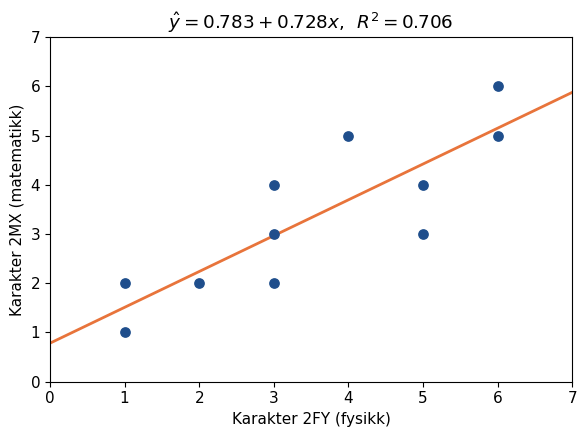

In [19]:
xs = np.linspace(0, 7, 50)
plt.figure(figsize=(6, 4.5))
plt.scatter(fy, mx, color=BLUE, s=45, zorder=3)
plt.plot(xs, res.intercept + res.slope * xs, color=ORANGE, lw=2)
plt.xlabel("Karakter 2FY (fysikk)")
plt.ylabel("Karakter 2MX (matematikk)")
plt.title(rf"$\hat y = {res.intercept:.3f} + {res.slope:.3f}x$,  $R^2={res.rvalue**2:.3f}$")
plt.xlim(0, 7); plt.ylim(0, 7)
plt.tight_layout()
plt.show()

In [20]:
# Prediksjon: en student med 3 i fysikk
fy_ny = 3
mx_pred = res.intercept + res.slope * fy_ny
print(f"Predikert 2MX-karakter for en student med {fy_ny} i 2FY: "
      f"{res.intercept:.3f} + {res.slope:.3f}*{fy_ny} = {mx_pred:.2f} (~ {round(mx_pred)})")

Predikert 2MX-karakter for en student med 3 i 2FY: 0.783 + 0.728*3 = 2.97 (~ 3)


### Forklaringsgrad: $R^2$

Beskriver hvor stor andel av variansen i y som forklares av regresjonsmodellen.
$R^2 = r^2$ (Pearsons r i annen) -- varierer mellom 0 og 1 (0-100 %). I karakter-eksempelet:
$R^2=0.706$ -- modellen forklarer ca. 71 % av variansen i mattekarakter. $R^2$ gir et mal pa
hvor god modellen er til a *predikere* den avhengige variabelen.

Under sammenlignes en modell med hoy $R^2$ og en med lav $R^2$:

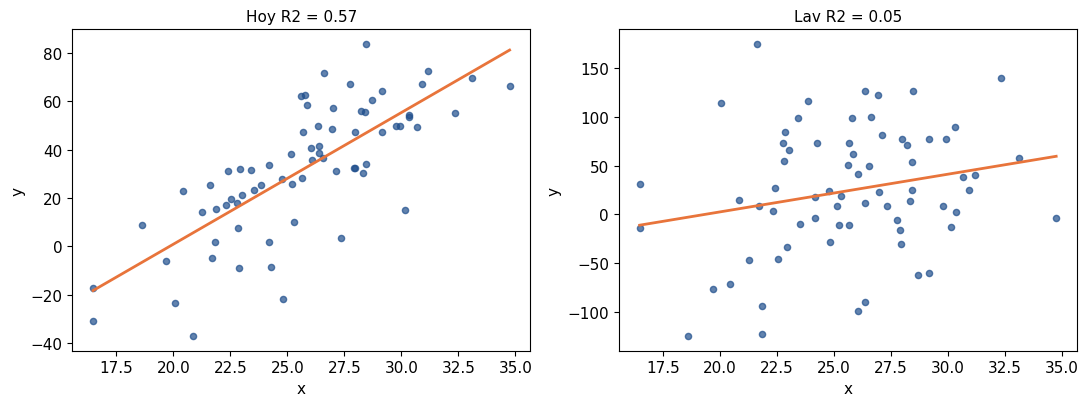

In [21]:
x8 = rng.normal(26, 4, 70)
y_high = 5 * x8 - 100 + rng.normal(0, 15, 70)
y_low = 2 * x8 - 20 + rng.normal(0, 60, 70)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, y8, ttl in zip(axes, [y_high, y_low], ["Hoy R2", "Lav R2"]):
    slope8, intercept8, r8, p8, se8 = stats.linregress(x8, y8)
    xs8 = np.linspace(x8.min(), x8.max(), 30)
    ax.scatter(x8, y8, color=BLUE, alpha=0.7, s=20)
    ax.plot(xs8, intercept8 + slope8 * xs8, color=ORANGE, lw=2)
    ax.set_title(f"{ttl} = {r8**2:.2f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### Eksempel: kroppshoyde som voksen

Kan man predikere voksen kroppshoyde ut fra hoyden som 2-aring? Lineaer regresjon pa n=73
personer (fra SPSS, radata ikke tilgjengelig her) ga:

$$\widehat{\text{Hoyde\_voksen}} = 70.71 + 1.2\cdot\text{Hoyde\_2}, \qquad R^2=0.253$$

In [22]:
alpha_h, beta_h, r2_h = 70.71, 1.2, 0.253

hoyde_2 = 80  # cm ved 2 ar
hoyde_voksen_pred = alpha_h + beta_h * hoyde_2
print(f"Predikert voksenhoyde for et barn som er {hoyde_2} cm ved 2 ar: "
      f"{alpha_h} + {beta_h}*{hoyde_2} = {hoyde_voksen_pred:.2f} cm")
print(f"\nR2 = {r2_h} er ganske lavt -- modellen er usikker, og datapunktene ligger "
      "forholdsvis spredt rundt linjen\n(mange andre faktorer enn 2-arshoyde pavirker voksenhoyde).")
print("\nMed radata ville stats.linregress(df['Hoyde_2'], df['Hoyde_voksen']) gitt identisk resultat.")

Predikert voksenhoyde for et barn som er 80 cm ved 2 ar: 70.71 + 1.2*80 = 166.71 cm

R2 = 0.253 er ganske lavt -- modellen er usikker, og datapunktene ligger forholdsvis spredt rundt linjen
(mange andre faktorer enn 2-arshoyde pavirker voksenhoyde).

Med radata ville stats.linregress(df['Hoyde_2'], df['Hoyde_voksen']) gitt identisk resultat.


## Oppsummering

| Begrep | Beskrivelse | Python |
|---|---|---|
| Krysstabell | Systematiserer to kategoriske variabler | `pd.crosstab` |
| Stablet stolpediagram | Viser andeler innad i grupper av ulik storrelse | `plt.bar(..., bottom=...)` |
| Spredningsdiagram | Viser sammenhengen mellom to kontinuerlige variabler visuelt | `plt.scatter` |
| Kovarians $s_{xy}$ | Retning pa samvariasjonen, men skalaavhengig | `np.cov(..., ddof=1)` |
| Pearsons $r$ | Normalisert kovarians, mellom -1 og 1 -- maler *lineaer* samvariasjon | `stats.pearsonr`, `np.corrcoef` |
| Linearitet | $r$ kan vaere naer 0 selv ved en sterk, ikke-lineaer sammenheng -- sjekk alltid spredningsdiagrammet! | -- |
| Korrelasjons-/kovariansmatrise | $r$ (eller $s_{xy}$) parvis for flere variabler | `df.corr()`, `df.cov()` |
| Regresjon | Finner den lineaere modellen $\hat y=\hat\alpha+\hat\beta x$ (minste kvadraters metode) og $R^2$ | `stats.linregress` |

Alle beregninger er gjort med `numpy`, `scipy.stats` og `pandas` i Python.